In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
sns.set()

In [31]:
class Precision():
    def __init__(self,file):
        #df = pd.read_csv(file,'\s+')
        df = pd.read_csv(file)
        self.df = df
        
    def plot_sigma(self,files,savefile):
        dat = {}
        print('lower case sigma, if file is uppercase sigma, switch')
        for f in files:
            sig = f.split('.csv')[0].split('sigma')[1].split('_Base')[0]
            thres = f.split('_Threhsold')[1].split('_')[0]
            if sig in dat.keys():
                dat[sig]=dat[sig].append(pd.read_csv(f,sep='\s+'))
            else:
                dat[sig] = pd.read_csv(f,sep='\s+')
        
        plots = len(files)
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            plt.subplot(2,3,i)
            #plt.hist(diffrecall,range = (-0.01,0.01))
            plt.hist(diffrecall)
            plt.title('Sigma:{}'.format(float(key)))
            i+=1
        #plt.suptitle(('Difference in Precision on Test Trials (Target-Output), Threshold: {}',float(thres)))
        plt.suptitle(('Threshold: {}'.format(float(thres))))
        plt.tight_layout()
        #plt.show()
        plt.savefig(savefile)
    

    def plot_sigma2(self,files,savefile):
        print('give files of only 1 sigma and multiple threshold')
        print('will plot both the histograms and 1 graph with rew. threshold and variance of histograms')
        dat = {}
        
        for f in files: 
            sig = f.split('.csv')[0].split('sigma')[1].split('_Base')[0]
            thres = f.split('_Threhsold')[1].split('_')[0]
            if thres in dat.keys():
                dat[thres]=dat[thres].append(pd.read_csv(f,sep='\s+'))
            else:
                dat[thres] = pd.read_csv(f,sep='\s+')
                
        stds = []
        means = []
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            stds.append(np.std(diffrecall))
            means.append(np.mean(diffrecall))
            #plt.subplot(2,4,i)
            ##plt.hist(diffrecall,range = (-0.01,0.01))
            #plt.hist(diffrecall)
            #plt.title('Threshold:{}'.format(float(key)))
            #i+=1
        #plt.subplot(2,4,8)
        plt.subplot(2,1,1)
        plt.scatter(list(dat.keys()),stds)
        plt.title('Sigma: {}, Std'.format(sig))
        plt.subplot(2,1,2)
        plt.scatter(list(dat.keys()),means)
        plt.title('Sigma: {}, Mean'.format(sig))
        plt.tight_layout()
            
    def get_diffs(self,df):
        df_include= []
        for i in df['$TrialName']:
            if 'Recall' in i:
                df_include.append('True')
            else:
                df_include.append('False')
        df.index = df_include
        df_recall = df.loc['True']

        #pull out target and actual decoded output for recall and all trials
        decodeout = df['#OutDecode']
        target = df['#OutTarget']
        decodeout_recall = df_recall['#OutDecode']
        target_recall = df_recall['#OutTarget']

        
        diff =np.array(decodeout)-np.array(target)
        self.alldiff = diff
        diffrecall =np.array(decodeout_recall)-np.array(target_recall)
        self.recalldiff = diffrecall
        return diff,diffrecall
        

    def plot_diffinperf(self,savefile):
        df = self.df
        diff,diffrecall= self.get_diffs(df)
        #make dataframe for just recall
        
        plt.subplot(1,2,1)
        plt.hist(diff)
        plt.xlabel('Difference')
        plt.ylabel('Frequency')
        plt.title('All Test Trials')
        plt.subplot(1,2,2)
        
        #plt.hist(diffrecall, range = (-0.01,0.01))
        plt.hist(diffrecall)
        plt.xlabel('Difference')
        plt.title('Recall Test Trials')
        plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.savefig(savefile)
    
    def plot_var_lesions(self,files,lesion_names,savefile):
        dat = {}
        for l in lesion_names:
            for f in files:
                if "Lesion"+l+"_" in f:
                    if l in dat.keys():
                        dat[l]=dat[l].append(pd.read_csv(f,sep='\s+'))
                    else:
                        dat[l] = pd.read_csv(f,sep='\s+') 
        self.lesiondat = dat
        plots = len(lesion_names)
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            plt.subplot(2,2,i)
            #plt.hist(diffrecall,range = (-0.01,0.01))
            plt.hist(diffrecall)
            plt.title('Lesion:{}'.format(key))
            i+=1
        #plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.tight_layout()
        plt.savefig(savefile)
    
    def plot_var_lesionprop(self,files,lesion_name,lesion_props,savefile):
        dat = {}
        for l in lesion_props:
            for f in files:
                if "LesionProp"+l+'_' in f:
                    if l in dat.keys():
                        dat[l]=dat[l].append(pd.read_csv(f,sep='\s+'))
                    else:
                        dat[l] = pd.read_csv(f,sep='\s+') 
        self.lesiondat = dat
        plots = len(lesion_props)
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            plt.subplot(3,2,i)
            #plt.hist(diffrecall,range = (-0.01,0.01))
            #plt.hist(diffrecall,bins = 30, range = (-3,3))
            plt.hist(diffrecall,bins = 30)
            plt.title('LesionProp:{}'.format(key))
            i+=1
        #plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.suptitle("{} Lesions".format(lesion_name))
        plt.tight_layout()
        plt.savefig(savefile)
    def plot_random_minus_fixed(self,files_random,files_fixed,lesion_name,lesion_props,savefile):
        print('this is not complete')
        #do what is in plot_var_lesionprop for random and fixed and then subtract before plotting   
        dat_random = {}
        dat_fixed = {}
        for l in lesion_props:
            for f in files_random:
                if "LesionProp"+l+'_' in f:
                    if l in dat_random.keys():
                        dat_random[l]=dat_random[l].append(pd.read_csv(f,sep='\s+'))
                    else:
                        dat_random[l] = pd.read_csv(f,sep='\s+') 
            for f in files_fixed:
                if "LesionProp"+l+'_' in f:
                    if l in dat_fixed.keys():
                        dat_fixed[l]=dat_fixed[l].append(pd.read_csv(f,sep='\s+'))
                    else:
                        dat_fixed[l] = pd.read_csv(f,sep='\s+') 
        self.dat_random = dat_random
        self.dat_fixed = dat_fixed
        plots = len(lesion_props)
        i = 1
        for key in dat_random.keys():
            _,diffrecall_random = self.get_diffs(dat_random[key])
            _,diffrecall_fixed = self.get_diffs(dat_fixed[key])
            self.diffrecall_random = diffrecall_random
            self.diffrecall_fixed = diffrecall_fixed
            plt.subplot(3,2,i)
            #plt.hist(diffrecall,range = (-0.01,0.01))
            #diff = diffrecall_random-diffrecall_fixed
            #self.diff = diff
            plt.hist(diffrecall_fixed,bins = 30, range = (-3,3))
            plt.title('LesionProp:{}'.format(key))
            i+=1
        #plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
        plt.suptitle("{} Lesions".format(lesion_name))
        plt.tight_layout()
        plt.savefig(savefile)
        
            
                
    def plot_num_stripe(self,files, stripes,savefile):
        dat = {}
        for f in files:
            for s in stripes:
                if s+'layers' in f:
                    if s in dat.keys():
                        #dat[s]=dat[s].append(pd.read_csv(f,sep='\s+'))
                        dat[s]=dat[s].append(pd.read_csv(f))
                    else:
                        #dat[s] = pd.read_csv(f,sep='\s+')
                        dat[s] = pd.read_csv(f)
        i = 1
        for key in dat.keys():
            _,diffrecall = self.get_diffs(dat[key])
            plt.subplot(2,2,i)
            plt.hist(diffrecall,bins = 30, range = (-3,3))
            plt.title('Lesion Number of Stripes:{}'.format(key))
            plt.suptitle("Stripe Lesions".format(key))
            i +=1
        plt.tight_layout()
        plt.savefig(savefile)
                    
                    
                
        

In [60]:
def silentsynapses(trialnames):
    same = []
    diff = []
    rew_same = []
    rew_diff = []
    for i in range(len(trialnames)):
        if 'Recall' in trialnames[i]:
            trial = trialnames[i]
            x = trial.split('Recall')[1].split('_')[1] #letter/stimulus
            xprev = trialnames[i-1].split('_')[1] #letter/stimulus from previous trial
            rew = int(trial.split('rew_')[1]) #reward

            if x == xprev:
                same.append(i)
                rew_same.append(rew)
            else:
                diff.append(i)
                rew_diff.append(rew)
    corr_same = np.mean(rew_same)
    print(rew_diff)
    corr_diff = np.mean(rew_diff)
    
    return(rew_same,rew_diff,corr_same,corr_diff)
        
    

give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms


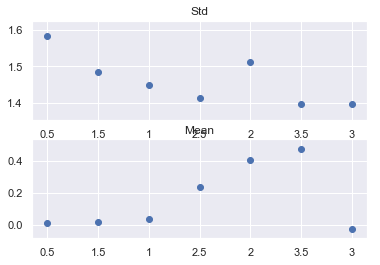

In [16]:
import os
#base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/RewThreshold/optimize_threhsold/'
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/RewThreshold/optimize_threshold/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'sigma0.005_' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'optimize_thresholdmodel0_Threhsold0.5_sigma0.005_Base.csv')
A.plot_sigma2(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/RewThreshold/optimize_threhsold/'+'OptSig0.005.png')

give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms


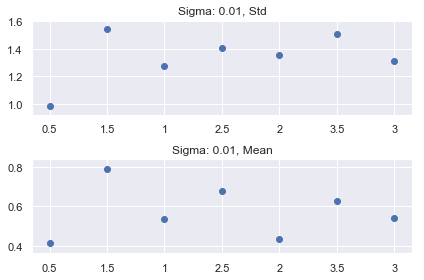

In [32]:
import os
#base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/RewThreshold/optimize_threhsold/'
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/RewThreshold/optimize_threshold/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'sigma0.01_' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'optimize_thresholdmodel0_Threhsold0.5_sigma0.01_Base.csv')
A.plot_sigma2(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/RewThreshold/optimize_threhsold/'+'OptSig0.01.png')

give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms
give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms
give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms
give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms
give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms
give files of only 1 sigma and multiple threshold
will plot both the histograms and 1 graph with rew. threshold and variance of histograms


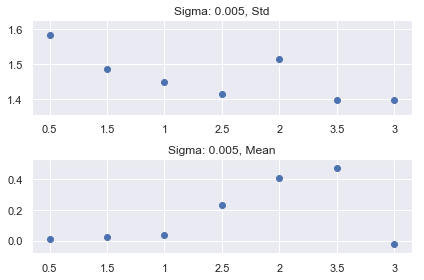

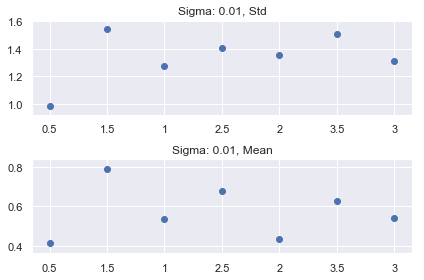

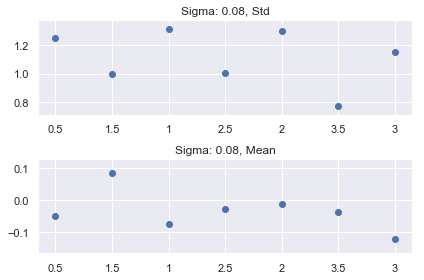

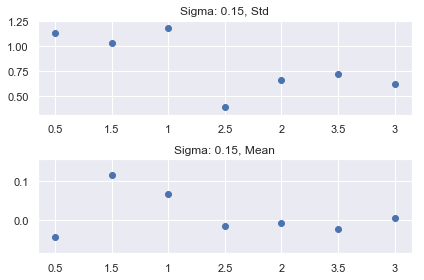

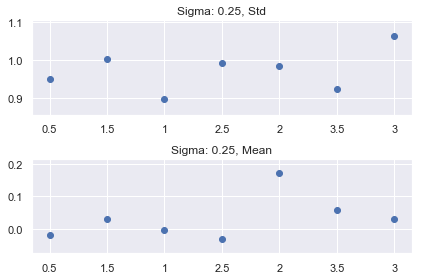

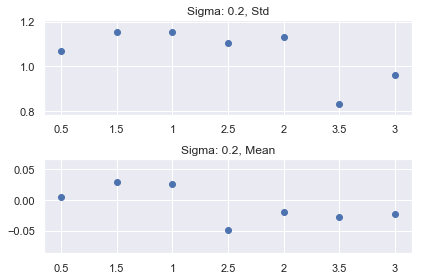

In [33]:
sigma = [0.005,0.01,0.08,0.15,0.25,0.2]
optimal_threshold =[]
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/RewThreshold/optimize_threshold/'
files = os.listdir(base)
for s in sigma: 
    plt.figure()
    files_sigma = []
    for f in files:
        if 'sigma'+str(s)+'_' in f: #can use this to select for specific threshold values 
            files_sigma.append(base+f)

    A = Precision(base+'optimize_thresholdmodel0_Threhsold0.5_sigma'+str(s)+'_Base.csv')
    A.plot_sigma2(files_sigma,base+'OptSig'+str(s)+'.png')

In [23]:
f = random_files[0]
a = pd.read_csv(f, sep = '\s+')
#seems that trial name is all we should need --> 
trial_name = np.array(a['$TrialName'])

In [71]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model4_LesionPFC_LesionProp0_Base.csv'
a = pd.read_csv(f, sep = '\s+')

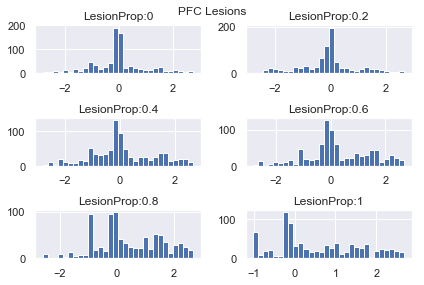

In [66]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionPFC_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden
lesion.plot_var_lesionprop(full_files,'PFC',["0","0.2","0.4","0.6","0.8","1"],base+'PFCLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

In [81]:
base ='C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/'
files = os.listdir(base)
lesion_type = 'LesionPFC_'
lesion_prop = 'LesionProp1_'
random_files = [base+f for f in files if np.logical_and(lesion_type in f, lesion_prop in f)]
rew_same_all = []
rew_diff_all = []
model = 0
for f in random_files:
    print(f)
    dat =pd.read_csv(f, sep = '\s+')
    trial_name = np.array(a['$TrialName'])
    rew_same,rew_diff,corr_same,corr_diff = silentsynapses(trial_name)
    print('Percent correct for same trials for model {} is {}'.format(model,corr_same))
    print('Percent correct for diff trials for model {} is {}'.format(model,corr_diff))
    rew_same_all.append(rew_same)
    rew_diff_all.append(rew_diff)
    model +=1

all_corr_same = np.mean(rew_same_all)
all_corr_diff = np.mean(rew_diff_all)
print('Percent correct for same trials is {}'.format(all_corr_same))
print('Percent correct for different trials is {}'.format(all_corr_diff))
    #dat.append(pd.read_csv(f), sep = '\s+') actually no point in appending because then need to make sure last trial of one run not affect first trial of next run
    


C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model0_LesionPFC_LesionProp1_Base.csv
[0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1]
Percent correct for same trials for model 0 is 0.26666666666666666
Percent correct for diff trials for model 0 is 0.23423423423423423
C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model1_LesionPFC_LesionProp1_Base.csv
[0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0

this is not complete


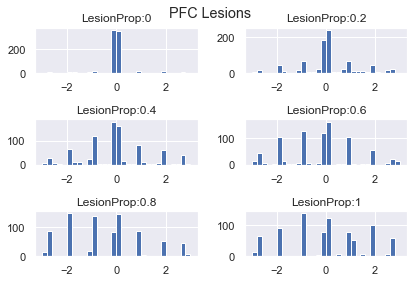

In [154]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
lesion_type = 'LesionPFC_' # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden

#random
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/'
files = os.listdir(base)
random_files = [base+f for f in files if lesion_type in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden

#fixed
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/FixedStimuli/'
files = os.listdir(base)
fixed_files = [base+f for f in files if lesion_type in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden

lesion.plot_random_minus_fixed(random_files,fixed_files,'PFC',["0","0.2","0.4","0.6","0.8","1"],base+'PFCRandoMinusFixedLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

In [66]:
len(lesion.diffrecall_random)
len(lesion.diffrecall_fixed)
#plt.hist(lesion.diffrecall_random[:831]-lesion.diffrecall_fixed)

831

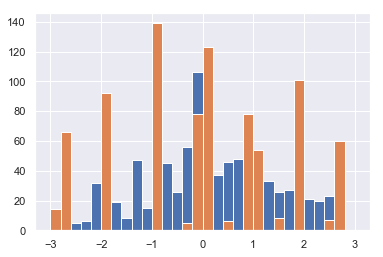

In [155]:
n_random,bins_random,patches_random = plt.hist(lesion.diffrecall_random,bins = 30, range = (-3,3))
n_fixed,bins_fixed,patches_fixed = plt.hist(lesion.diffrecall_fixed,bins = 30, range = (-3,3))

In [117]:
np.mean([])

nan

Text(0.5, 1.0, 'Difference between Random and Fixed')

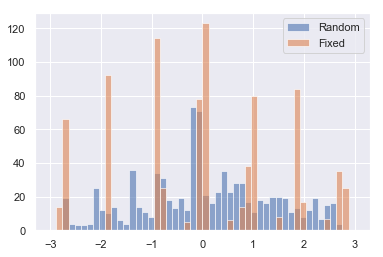

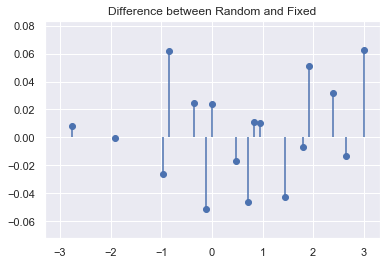

In [158]:
diffrecall_random = lesion.diffrecall_random
diffrecall_fixed = lesion.diffrecall_fixed
n_random,bins_random,patches_random = plt.hist(lesion.diffrecall_random,bins = 50, range = (-3,3), alpha = 0.6)
n_fixed,bins_fixed,patches_fixed = plt.hist(lesion.diffrecall_fixed,bins = 50, range = (-3,3), alpha = 0.6)
plt.legend({'Random', 'Fixed'})
b_rand = []
b_fixed = []
for b in range(len(bins_random)):
    if b==(len(bins_random)-1):
        b_rand.append(np.mean(diffrecall_random[(diffrecall_random<=bins_random[b])]))
        b_fixed.append(np.mean(diffrecall_fixed[(diffrecall_fixed<=bins_fixed[b])]))
    else:
        b_rand.append(np.mean(diffrecall_random[np.logical_and(diffrecall_random>=bins_random[b],diffrecall_random<bins_random[b+1])]))
        b_fixed.append(np.mean(diffrecall_fixed[np.logical_and(diffrecall_fixed>=bins_fixed[b],diffrecall_fixed<bins_fixed[b+1])]))
diff = np.array(b_rand)-np.array(b_fixed)
lines = []
for i in range(len(diff)):
    pair=[(bins_random[i],0), (bins_random[i], diff[i])]
    lines.append(pair)

linecoll = matcoll.LineCollection(lines)
fig, ax = plt.subplots()
ax.add_collection(linecoll)
plt.scatter(bins_random,diff)
plt.title('Difference between Random and Fixed')


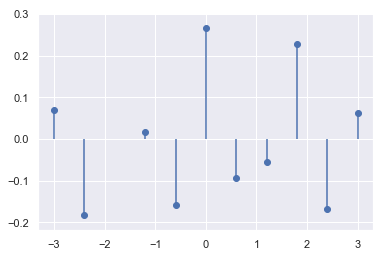

In [142]:
diff = np.array(b_rand)-np.array(b_fixed)
lines = []
for i in range(len(diff)):
    pair=[(bins_random[i],0), (bins_random[i], diff[i])]
    lines.append(pair)

linecoll = matcoll.LineCollection(lines)
fig, ax = plt.subplots()
ax.add_collection(linecoll)
plt.scatter(bins_random,diff)


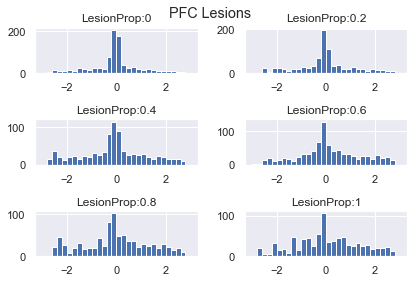

In [6]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionPFC_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden
lesion.plot_var_lesionprop(full_files,'PFC',["0","0.2","0.4","0.6","0.8","1"],base+'PFCLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

In [40]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model4_LesionPFC_LesionProp0.8_Base.csv'
df = pd.read_csv(file,sep='\s+')
np.mean(df['$LesionApplied']=='yes')

0.792

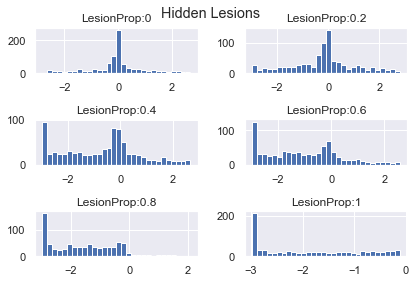

In [151]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionHidden_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden
lesion.plot_var_lesionprop(full_files,'Hidden',["0","0.2","0.4","0.6","0.8","1"],base+'HiddenLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

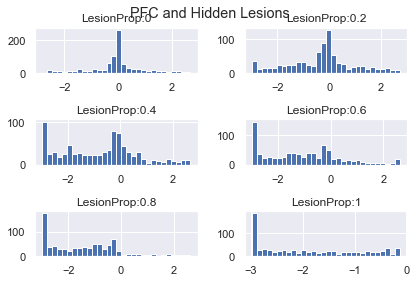

In [152]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/RandomStimuli/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionPFCHidden_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden
lesion.plot_var_lesionprop(full_files,'PFC and Hidden',["0","0.2","0.4","0.6","0.8","1"],base+'PFCHiddenLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

In [315]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_stripes = []
for f in files:
    if np.logical_and('capacity' in f, '.csv' in f):
        files_stripes.append(base+f)

In [316]:
files_stripes

['C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_1layers.csv',
 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_2layers.csv',
 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_3layers.csv',
 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_4layers.csv']

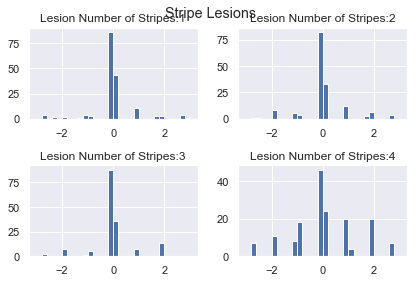

In [350]:
lesion = Precision(file)
lesion.plot_num_stripe(files_stripes,['1','2','3','4'],'base'+'stripelesions.png')
#why does lesioning all 4 stripes not lead to what the PFC prop = 1 lesion looked like - compeltely uniform?? is it not a full lesion. 

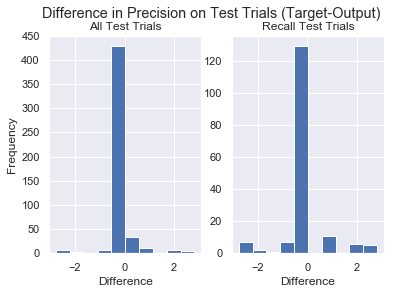

In [301]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity.csv'
lesion = Precision(file)
lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity.png')

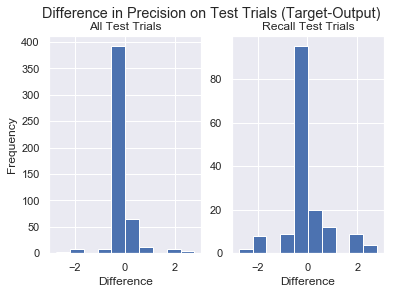

In [302]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_2layers.csv'
lesion = Precision(file)
lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_2layers.png')

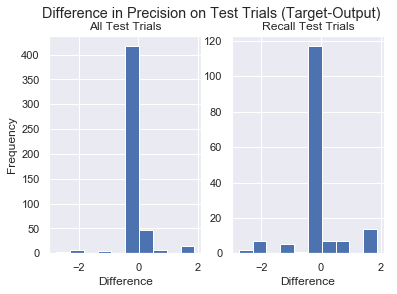

In [303]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_3layers.csv'
lesion = Precision(file)
lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_3layers.png')

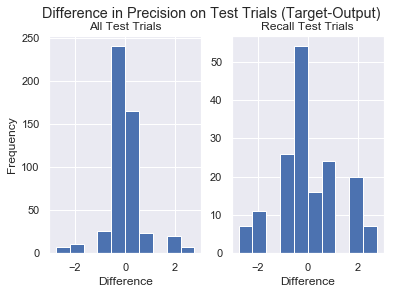

In [305]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_4layers.csv'
lesion = Precision(file)
lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/capacity_4layers.png')

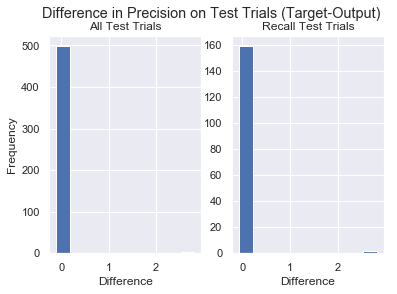

In [198]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/trial0.15_Base.csv'
lesion = Precision(file)
lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/trialone_PFC_prop0')

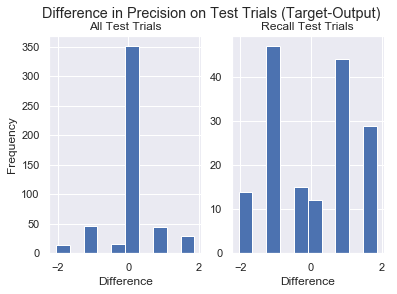

In [199]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/model0_LesionHidden_LesionProp0_Base.csv'
lesion = Precision(file)
lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

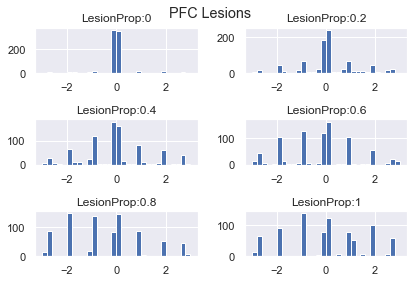

In [249]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionPFC_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden
lesion.plot_var_lesionprop(full_files,'PFC',["0","0.2","0.4","0.6","0.8","1"],base+'PFCLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

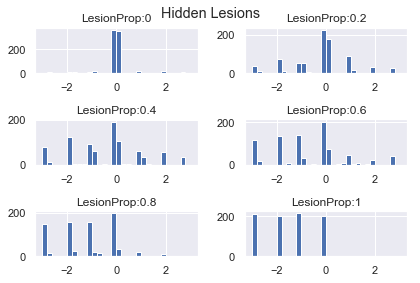

In [250]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionHidden_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden
lesion.plot_var_lesionprop(full_files,'Hidden',["0","0.2","0.4","0.6","0.8","1"],base+'HiddenLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

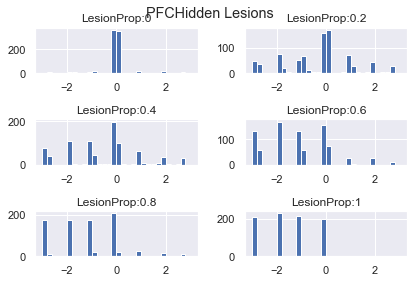

In [251]:
file = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/model4_LesionPFC_LesionProp0_Base.csv'
lesion = Precision(file)
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15_Trial2/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionPFCHidden_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden
lesion.plot_var_lesionprop(full_files,'PFCHidden',["0","0.2","0.4","0.6","0.8","1"],base+'PFCHiddenLesions.png')
#lesion.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/trialmodel0prop0.png')

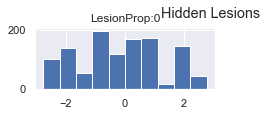

In [179]:
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.15/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionHidden_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden"
lesion = Precision(base+'model0_LesionHidden_LesionProp0.2_Base.csv')
lesion.plot_var_lesionprop(full_files, 'Hidden',["0"],base+'lesions_sir2_VarLesionsHidden.png')

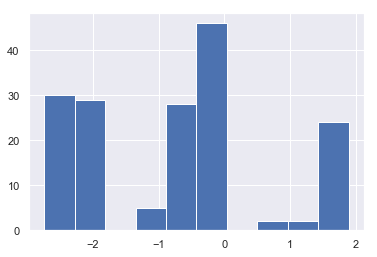

In [193]:
def get_diffs(df):
    df_include= []
    for i in df['$TrialName']:
        if 'Recall' in i:
            df_include.append('True')
        else:
            df_include.append('False')
    df.index = df_include
    df_recall = df.loc['True']

    #pull out target and actual decoded output for recall and all trials
    decodeout = df['#OutDecode']
    target = df['#OutTarget']
    decodeout_recall = df_recall['#OutDecode']
    target_recall = df_recall['#OutTarget']


    diff =np.array(decodeout)-np.array(target)
    diffrecall =np.array(decodeout_recall)-np.array(target_recall)
    return diff,diffrecall
diff,diffrecall =get_diffs(lesion.lesiondat['0'][1000:1500])
plt.hist(diffrecall)
plt.show()

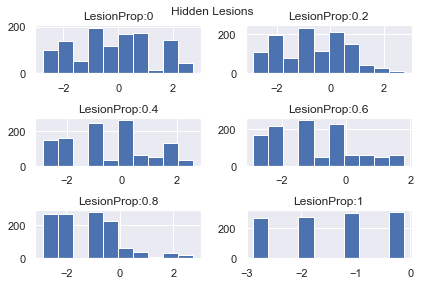

In [146]:
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionHidden_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden"
lesion = Precision(base+'model0_LesionHidden_LesionProp0.2_Base.csv')
lesion.plot_var_lesionprop(full_files, 'Hidden',["0","0.2","0.4","0.6","0.8","1"],base+'lesions_sir2_VarLesionsHidden.png')

In [158]:
d = lesion.lesiondat

In [161]:
d['0']

3500

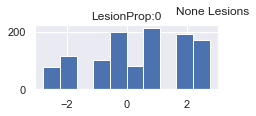

In [156]:
les = "None"
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/Sig0.08/'
files = os.listdir(base)
full_files = [base+f for f in files if 'Lesion'+les+"_" in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden"
lesion = Precision(base+'model0_Lesion'+les+'_LesionProp0_Base.csv')
lesion.plot_var_lesionprop(full_files, les,["0"],base+'lesions_sir2sig0.08_Lesions'+les+'.png')

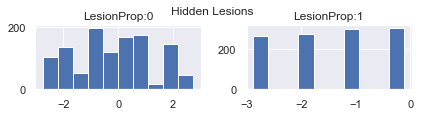

In [149]:
#this is set up to plot the various lesion proportions for PFC - need to just add the proportions
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/'
files = os.listdir(base)
full_files = [base+f for f in files if 'LesionHidden_' in f] # need to use "LesionHidden_" "LesionPFC_" or "LesionPFCHidden"
lesion = Precision(base+'model0_LesionHidden_LesionProp0.2_Base.csv')
lesion.plot_var_lesionprop(full_files, 'Hidden',["0","1"],base+'lesions_sir2_LesionsHidden.png')

In [90]:
f = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/_LesionPFC_LesionProp0.5_Base.csv'
df = pd.read_csv(f,sep='\s+')

In [112]:
dfnew = {}
for C in df.columns:
    if "PFCmnt" in C:
        dfnew[C] = df[C]
    if "LesionApplied" in C:
        dfnew[C] = df[C]
    if "TrialName" in C:
        dfnew[C] = df[C]

In [113]:
DF = pd.DataFrame.from_dict(dfnew)

In [91]:
LA = df['$LesionApplied']

In [92]:
print(np.sum(LA=='yes'))
print(np.sum(LA=='no'))

253
247


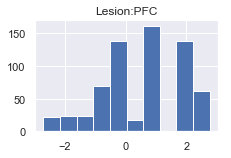

In [69]:
base= 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/PropLesions/'
files = os.listdir(base)
full_files = [base+f for f in files]
lesion = Precision(base+'model0_LesionPFC_LesionProp0.5_Base.csv')
lesion.plot_var_lesions(full_files, ['PFC'],base+'lesions_sir2_0.5PropPFC.png')

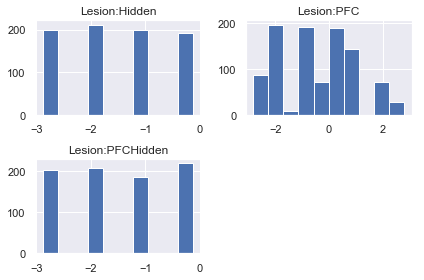

In [67]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/Lesions/'
files = os.listdir(base)
full_files = [base+f for f in files]
lesion = Precision(base+'model0_LesionPFC_Base.csv')
lesion.plot_var_lesions(full_files, ['Hidden','PFC','PFCHidden'],base+'lesions_sir2_sig0.15.png')

lower case sigma, if file is uppercase sigma, switch


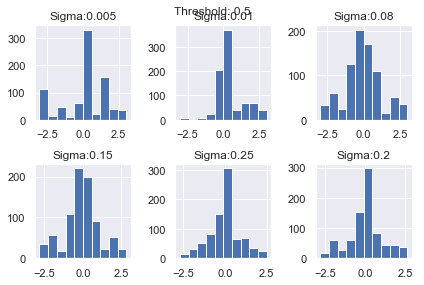

In [40]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'Threhsold0.5' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/'+'OptSigmaSir2Thres0.5Models.png')

lower case sigma, if file is uppercase sigma, switch


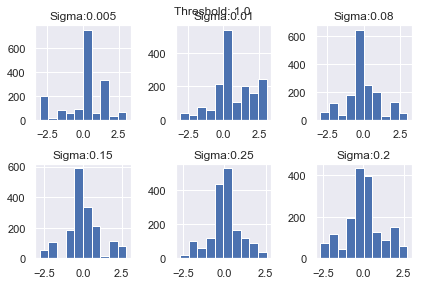

In [41]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'Threhsold1' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/'+'OptSigmaSir2Thres1Models.png')

lower case sigma, if file is uppercase sigma, switch


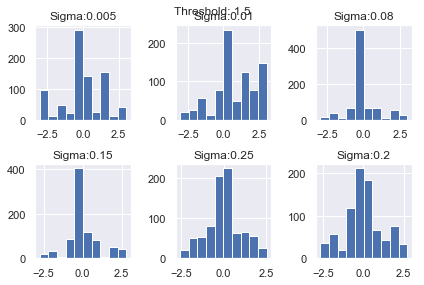

In [42]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'Threhsold1.5' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/'+'OptSigmaSir2Thres1.5Models.png')

lower case sigma, if file is uppercase sigma, switch


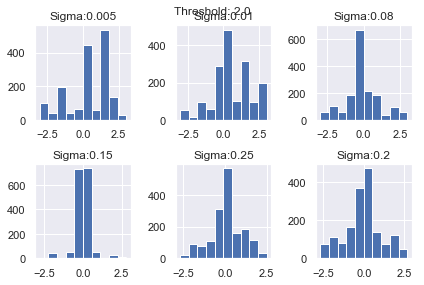

In [43]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'Threhsold2' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/'+'OptSigmaSir2Thres2Models.png')

lower case sigma, if file is uppercase sigma, switch


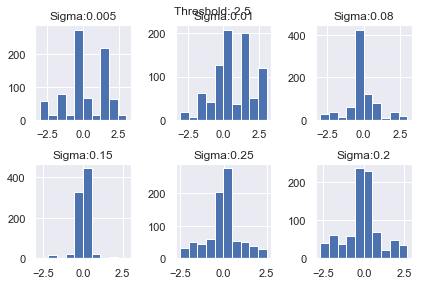

In [44]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'Threhsold2.5' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/'+'OptSigmaSir2Thres2.5Models.png')

lower case sigma, if file is uppercase sigma, switch


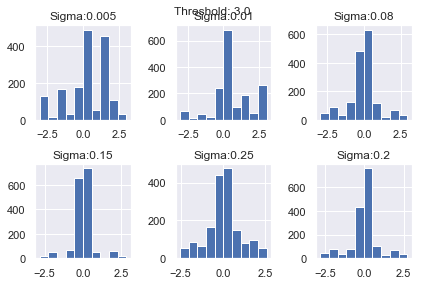

In [45]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'Threhsold3' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/'+'OptSigmaSir2Thres3Models.png')

lower case sigma, if file is uppercase sigma, switch


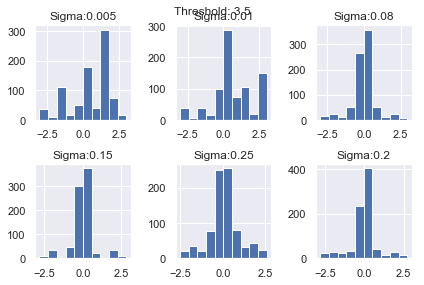

In [46]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir2/'
files = os.listdir(base)
files_sigma = []
for f in files:
    if 'Threhsold3.5' in f: #can use this to select for specific threshold values 
        files_sigma.append(base+f)

A = Precision(base+'model0_sigma0.005_Base.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/'+'OptSigmaSir2Thres3.5Models.png')

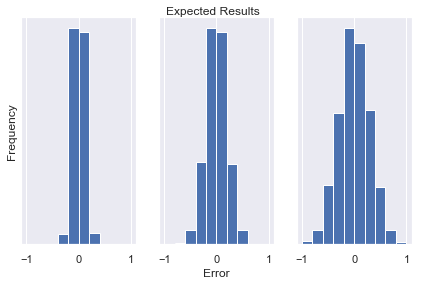

In [131]:
plt.subplot(1,3,1)
x = np.random.normal(0,0.1,10000)
plt.hist(x,range = [-1,1])
plt.yticks([])
plt.ylabel('Frequency')
#plt.title('No Lesion')
plt.subplot(1,3,2)
x = np.random.normal(0,0.2,10000)
plt.hist(x,range = [-1,1])
plt.xlabel('Error')
#plt.ylabel('Frequency')
#plt.title('Lesion')
plt.yticks([])
plt.subplot(1,3,3)
x = np.random.normal(0,0.3,10000)
plt.hist(x,range = [-1,1])
#plt.xlabel('Error')
#plt.ylabel('Frequency')
plt.yticks([])
plt.suptitle('Expected Results')
plt.tight_layout()
plt.show()

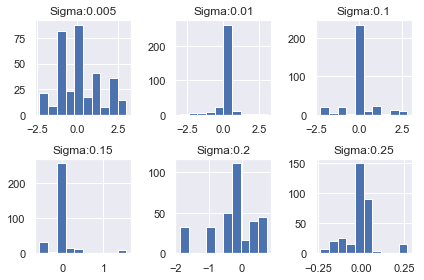

In [59]:
A = Precision(base+'Threshold3.4Sigma0.005.csv')
A.plot_sigma(files_sigma,'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'PrecisionvariousSigmaSir2.png')

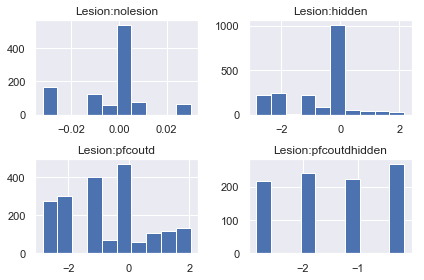

In [92]:
import os
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
files = os.listdir(base)
files_lesion = []
for f in files:
    #if np.logical_and('sig0.15'in f,'2' not in f): #can use this to select for specific threshold values 
    if 'sig0.15' in f:
        files_lesion.append(base+f)
lesion = Precision(base+'sig0.15hiddenlesion.csv')
lesion.plot_var_lesions(files_lesion, ['nolesion','hidden','pfcoutd','pfcoutdhidden'],base+'lesions_sir1_sig0.15.png')

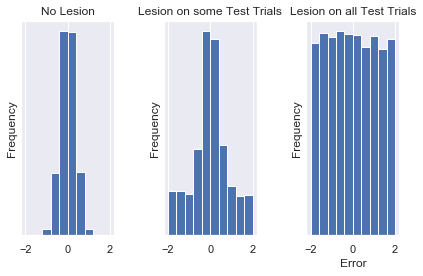

In [295]:
plt.subplot(1,3,1)
x = np.random.normal(0,0.35,100000)
plt.hist(x,range = [-2,2])
plt.yticks([])
plt.ylabel('Frequency')
plt.title('No Lesion')

plt.subplot(1,3,2)
x1 = np.random.normal(0,0.35,1000)
x2 = np.random.uniform(-2,2,1000)
plt.hist(np.concatenate([x1,x2]),range = [-2,2])
plt.yticks([])
plt.ylabel('Frequency')
plt.title('Lesion on some Test Trials')

plt.subplot(1,3,3)
x = np.random.uniform(-2,2,10000)
plt.hist(x)
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Lesion on all Test Trials')
plt.yticks([])
#plt.suptitle('Expected Results')
plt.tight_layout()
plt.show()

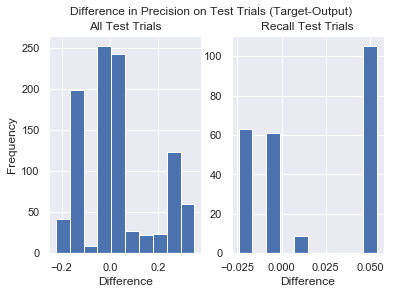

In [28]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
B = Precision(base+'lesionhidden')
B.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'sir1lesionhidden.png')

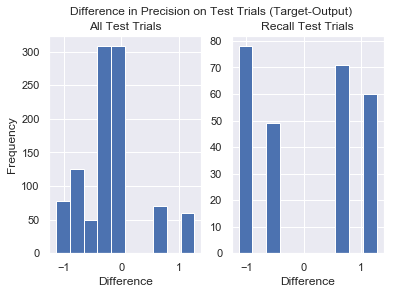

In [29]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
B = Precision(base+'lesionPFCoutD.csv')
B.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'sir1lesionPFCoutD.png')

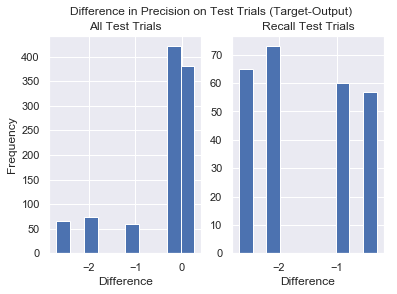

In [30]:
base = 'C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis/TestData/sir1/'
B = Precision(base+'lesionPFCoutDhidden.csv')
B.plot_diffinperf('C:/Users/Aneri/go/src/leabra/examples/sir_proj/analysis'+'sir1lesionPFCoutD.png')

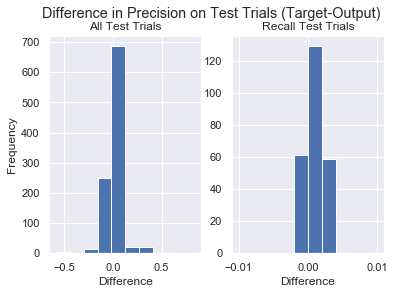

In [165]:
A = Precision(base+'TestData/1000TrialsSigma0.1.csv')
A.plot_diffinperf(base+'DiffinPerf.png')

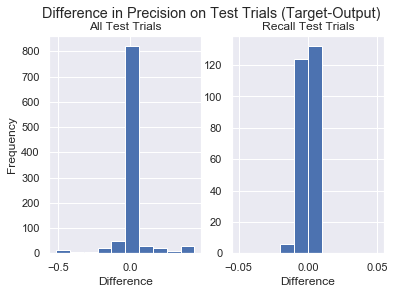

In [116]:
A = Precision('C:/Users/Aneri/go/src/sims/ch10/sir_proj/sir1/workingmemory/TestData/tsttrllogdata1000.csv')
A.plot_diffinperf('C:/Users/Aneri/go/src/sims/ch10/sir_proj/sir1/workingmemory/DifferenceinPerf1000.png')

In [77]:
df = pd.read_csv('Desktop/tsttrllogdata500.csv')

In [78]:
#make dataframe for just recall
df_include= []
for i in df['$TrialName']:
    if 'Recall' in i:
        df_include.append('True')
    else:
        df_include.append('False')
df.index = df_include
df_recall = df.loc['True']

In [79]:
#pull out target and actual decoded output for recall and all trials
decodeout = df['#OutDecode']
target = df['#OutTarget']
decodeout_recall = df_recall['#OutDecode']
target_recall = df_recall['#OutTarget']

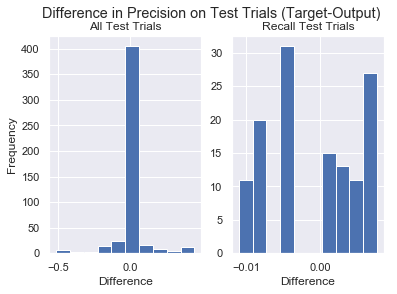

In [80]:
plt.subplot(1,2,1)
diff =np.array(decodeout)-np.array(target)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('All Test Trials')
plt.subplot(1,2,2)
diff =np.array(decodeout_recall)-np.array(target_recall)
plt.hist(diff)
plt.xlabel('Difference')
plt.title('Recall Test Trials')
plt.suptitle('Difference in Precision on Test Trials (Target-Output)')
plt.show()

In [ ]:
diff =np.array(decodeout)-np.array(target)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Difference in Precision on Recall Test Trials (Target - Output)')
plt.show()

In [22]:
cor = []
for i in trial_name:
    if '_A_mnt' in i:
        cor.append(0)
    if '_B_mnt' in i:
        cor.append(1)
    if '_C_mnt' in i:
        cor.append(2)
    if '_D_mnt' in i:
        cor.append(3)
out = []
for i in decodeout:
    out.append(i)

In [28]:
cor

[1, 0, 3, 2, 0, 3, 2, 1, 0, 1, 1, 2, 1, 1, 0, 0, 0, 1, 2, 2]

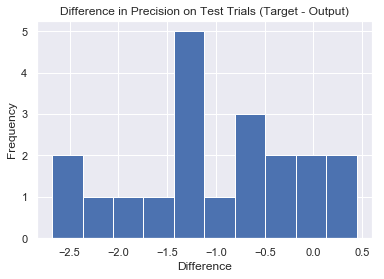

In [34]:
diff =np.array(cor)-np.array(out)
plt.hist(diff)
plt.xlabel('Difference')
plt.ylabel('Frequency')
plt.title('Difference in Precision on Test Trials (Target - Output)')
plt.show()